#### This dataset contains about 10 years of daily weather observations from numerous Australian weather stations.
#### The target RainTomorrow means: Did it rain the next day? Yes or No.

#### Load the library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the dataset

In [2]:
df = pd.read_csv('weatherAUS.csv')

In [3]:
df.shape

(145460, 23)

In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


#### Data Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

#### Check Duplicates

In [7]:
df[df.duplicated()]

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow


In [8]:
df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

#### Handling misssing values

In [9]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [10]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [11]:
df.shape

(145460, 23)

## Checking outliers

In [12]:
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

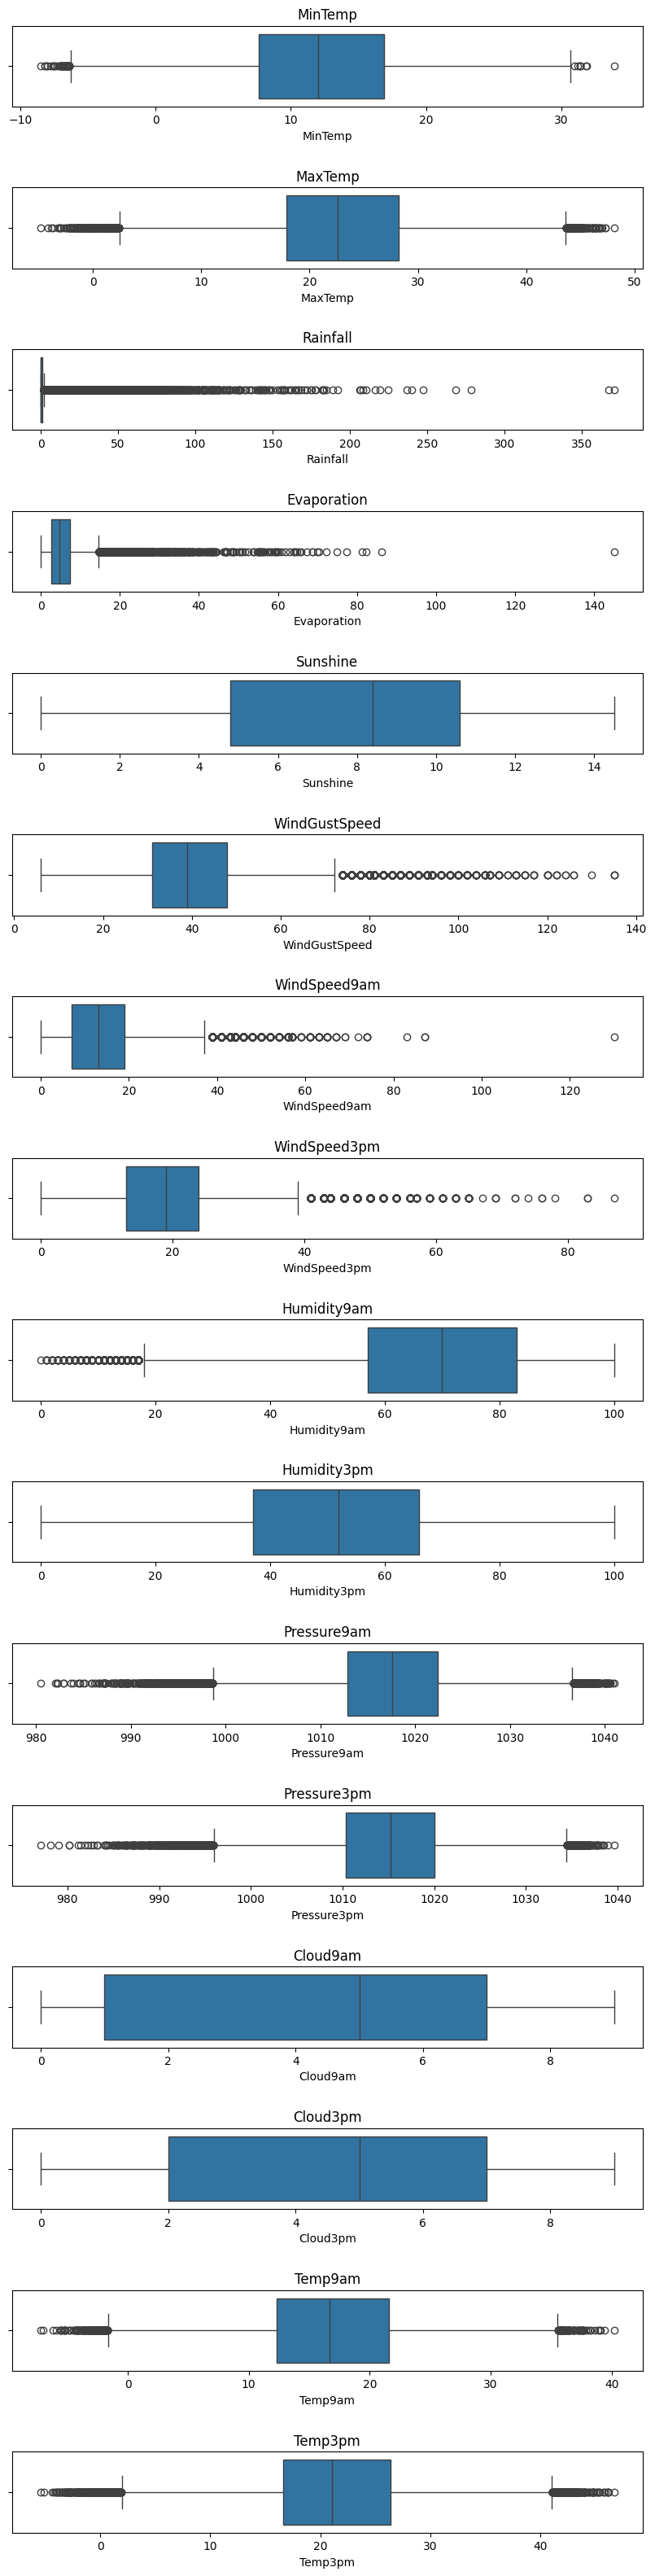

In [13]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 40))

for i, col in enumerate(num_columns):
    sns.boxplot(data=df, x=col, ax=axes[i]) 
    axes[i].set_title(col)
    plt.subplots_adjust(hspace=1) 

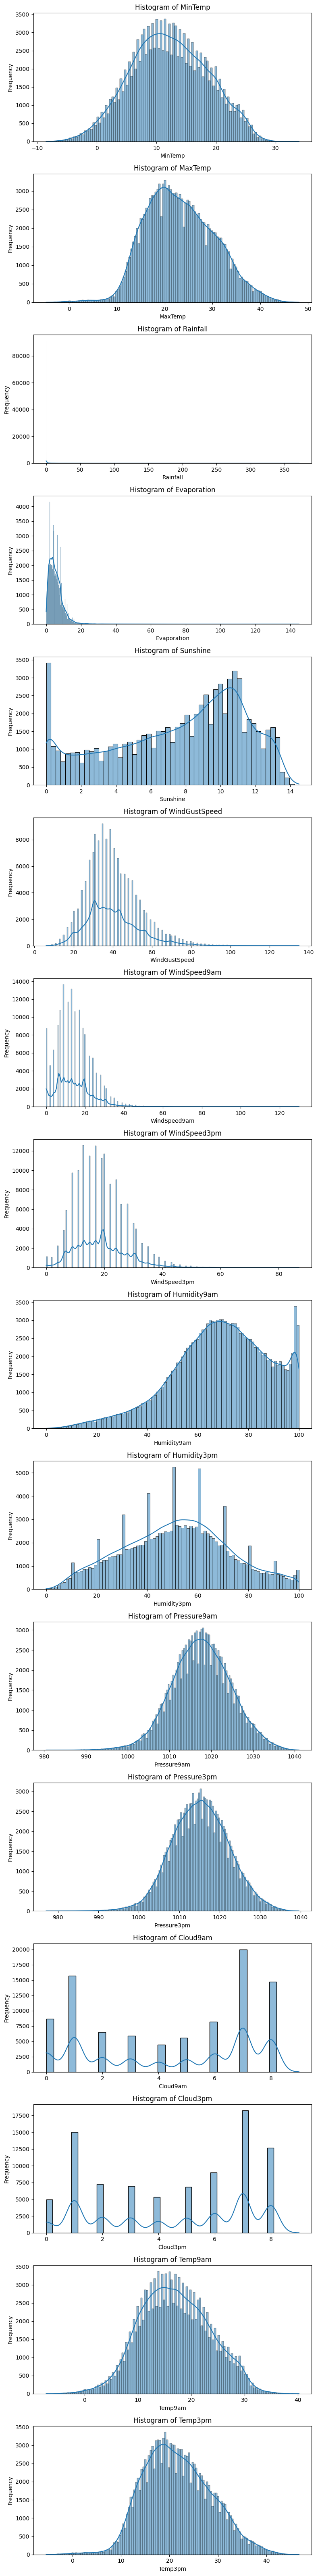

In [14]:
continuous = [col for col in df.columns if df[col].dtype != object]
fig, axes = plt.subplots(nrows=len(continuous), ncols=1, figsize=(8, len(continuous) * 4))
if len(continuous) == 1:
    axes = [axes]

for i, col in enumerate(continuous):
    sns.histplot(df[col], kde=True, ax=axes[i])  
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout() 
plt.show()

In [15]:
num_column_mean = ['MinTemp','MaxTemp','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm']        
num_column_median = ['Rainfall','Evaporation','Sunshine','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Humidity9am','Cloud9am','Cloud3pm']

#### Filling null values with the mean and median

In [16]:
for i in num_column_mean:
    mean =df[i].mean()
    print(i,":",mean)
    df.fillna({i:mean}, inplace=True)   
for i in num_column_median:
    median =df[i].median()
    print(i,":",median)
    df.fillna({i:median}, inplace=True)   

MinTemp : 12.19403438096892
MaxTemp : 23.22134827564685
Humidity3pm : 51.5391158755046
Pressure9am : 1017.6499397983052
Pressure3pm : 1015.2558888309618
Temp9am : 16.990631415587398
Temp3pm : 21.68339031800974
Rainfall : 0.0
Evaporation : 4.8
Sunshine : 8.4
WindGustSpeed : 39.0
WindSpeed9am : 13.0
WindSpeed3pm : 19.0
Humidity9am : 70.0
Cloud9am : 5.0
Cloud3pm : 5.0


#### Removing Outlier with Max and min values

In [17]:
for i in num_columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)]
    #print(outliers)
    df.loc[df[i]>upper_bound,i]=upper_bound
    df.loc[df[i]<lower_bound,i]=lower_bound

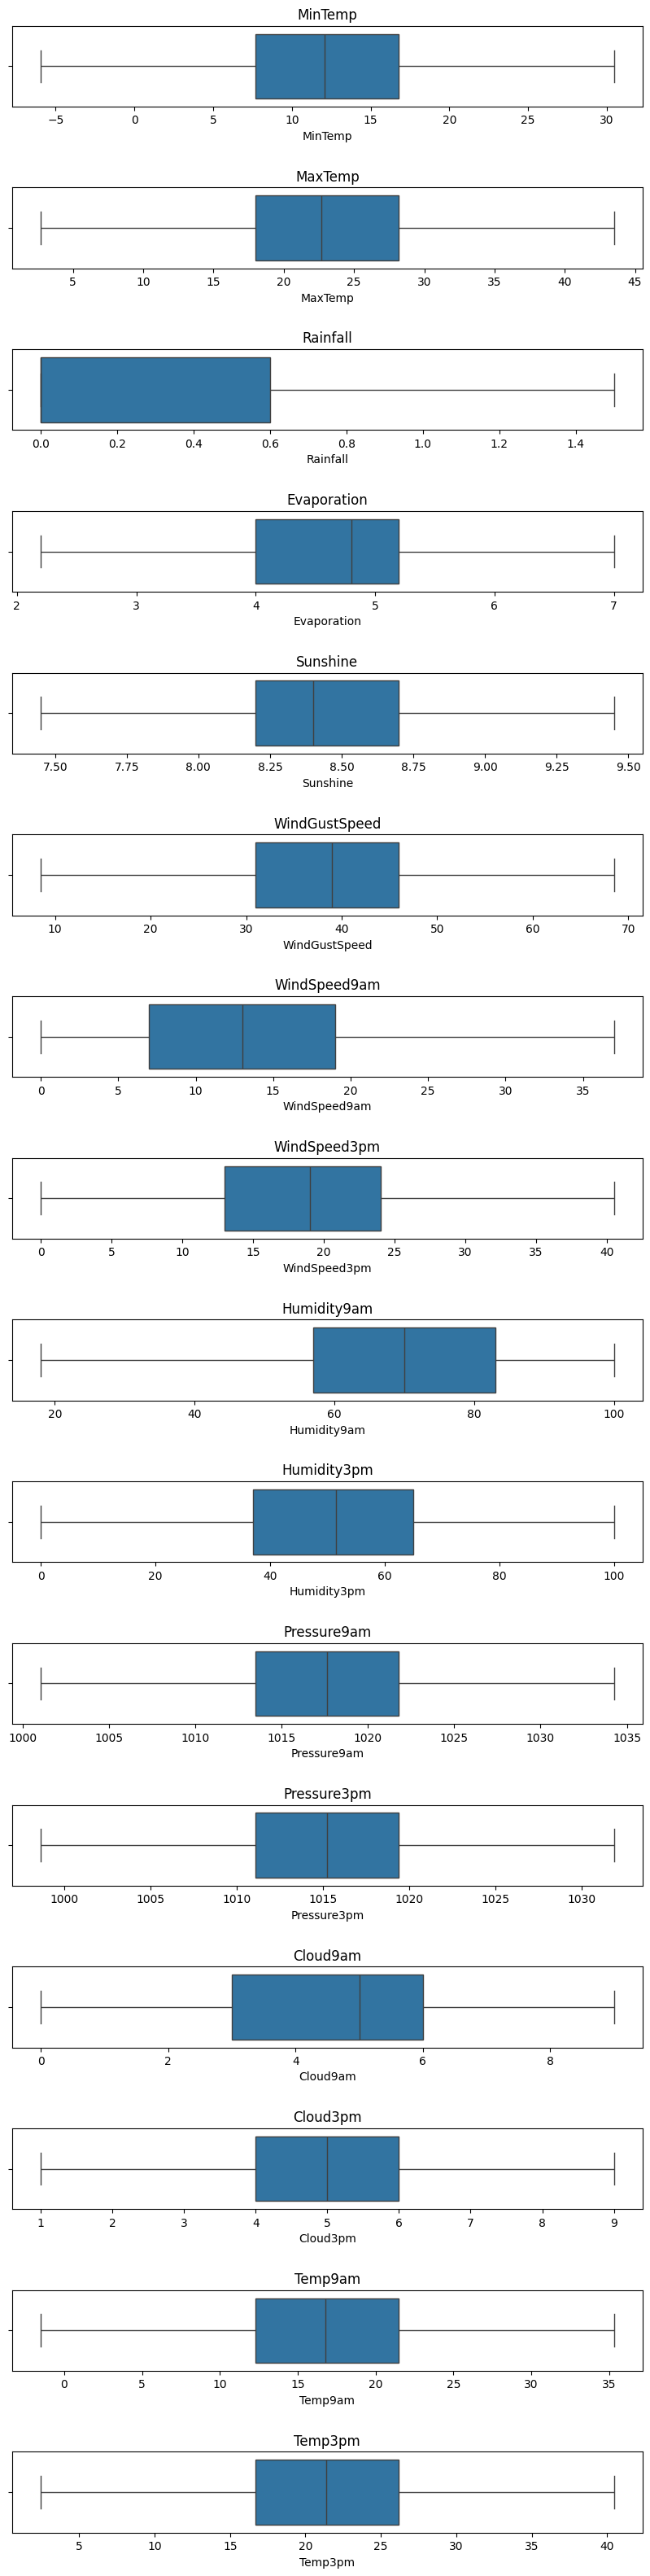

In [18]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 40))

for i, col in enumerate(num_columns):
    sns.boxplot(data=df, x=col, ax=axes[i]) 
    axes[i].set_title(col)
    plt.subplots_adjust(hspace=1) 

# check correlation

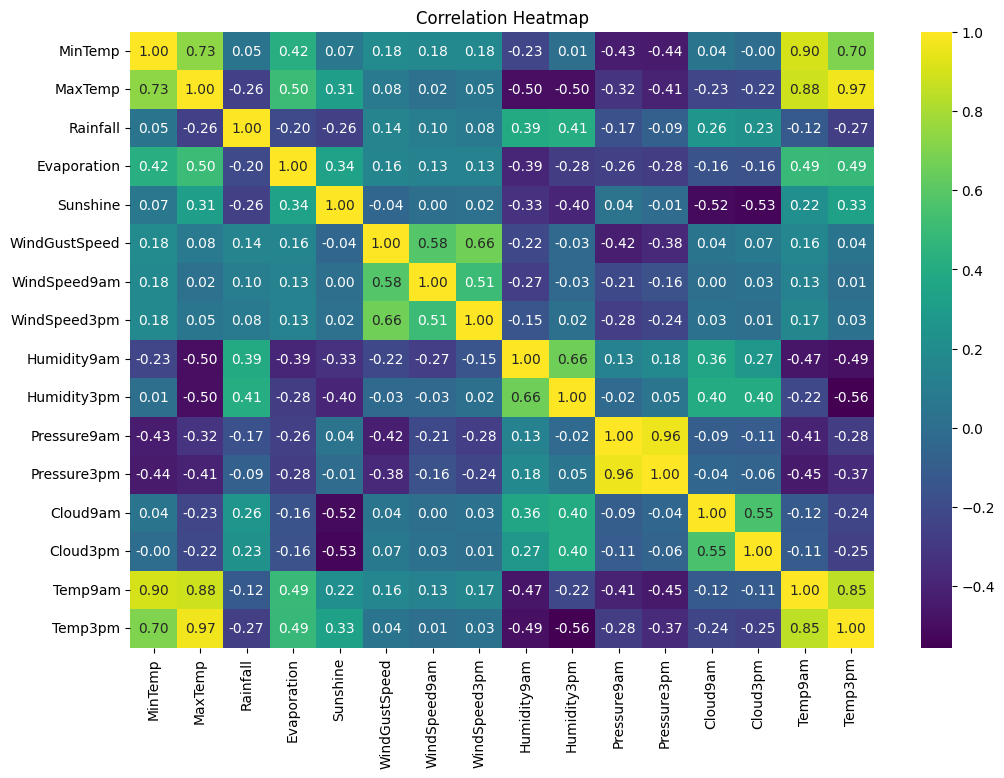

In [19]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df[continuous].corr(), annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
df = df.drop(columns=['Temp9am','Temp3pm','Pressure9am'])

In [21]:
continuous = [col for col in df.columns if df[col].dtype != object]

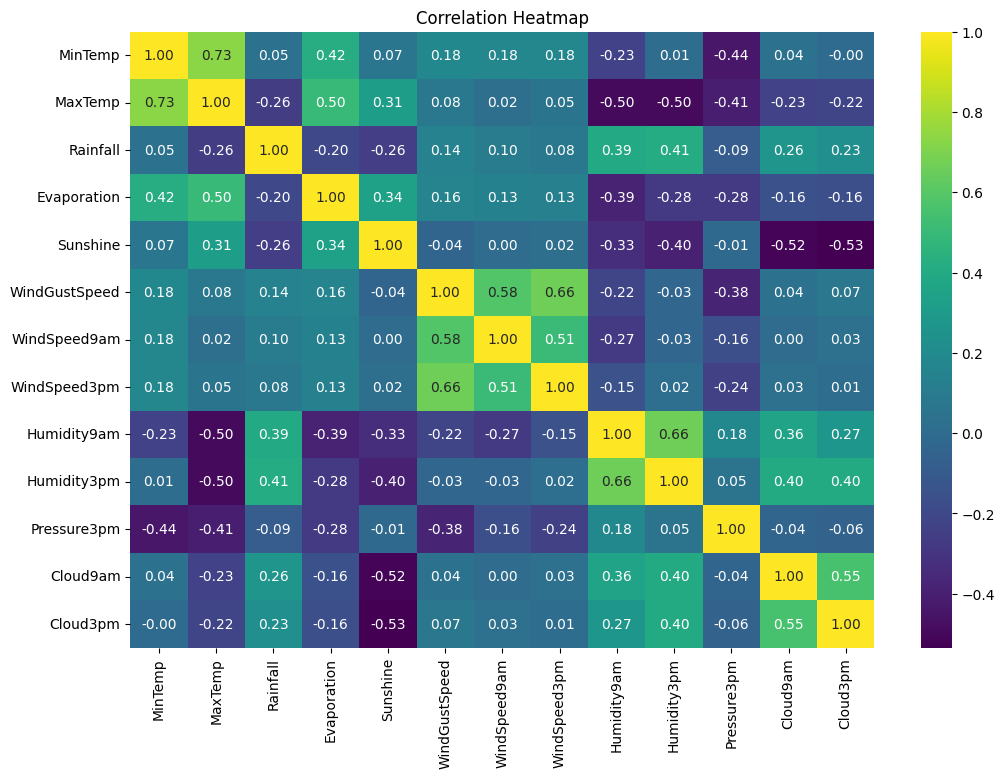

In [22]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df[continuous].corr(), annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure3pm    145460 non-null  float64
 16  Cloud9am       145460 non-null  float64
 17  Cloud3pm       145460 non-nul

#### Drop the Date columns

In [24]:
df=df.drop('Date',axis=1)

In [25]:
df = df.drop_duplicates()

In [26]:
df.shape

(145210, 19)

#### Select the Categorical columns

In [27]:
cat_columns = df.select_dtypes(include=['object']).columns.tolist()

#### Null values in the Categorical columns

In [28]:
for i in cat_columns:
    print(i ,":",df[i].isnull().sum())

Location : 0
WindGustDir : 10076
WindDir9am : 10316
WindDir3pm : 3978
RainToday : 3057
RainTomorrow : 3064


#### Filling null values with the mode in categorical columns

In [29]:
for i in cat_columns:
    mode_cat =df[i].mode()
    mode_i = df[i].mode()[0]
    print(mode_i)
    df.fillna({i:mode_i}, inplace=True)   

Canberra
W
N
SE
No
No


In [30]:
for i in cat_columns:
    print(i ,":",df[i].isnull().sum())

Location : 0
WindGustDir : 0
WindDir9am : 0
WindDir3pm : 0
RainToday : 0
RainTomorrow : 0


In [31]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.1,8.0,5.0,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1007.8,5.0,5.0,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1008.7,5.0,2.0,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1012.8,5.0,5.0,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1006.0,7.0,8.0,No,No


#### Scaling 

In [32]:
num_columns = [col for col in df.columns if df[col].dtype != object]

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [34]:
df[num_columns] = scaler.fit_transform(df[num_columns])

#### Classify X and Y

In [35]:
y = df['RainTomorrow']
X = df.drop('RainTomorrow',axis=1)

In [36]:
X.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'RainToday'],
      dtype='object')

In [37]:
for i in cat_columns:
    print(df[i].unique())
    print("=================================")

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']
['W' 'WNW' 'WSW' 'NE' 'NNW' 'N' 'NNE' 'SW' 'ENE' 'SSE' 'S' 'NW' 'SE' 'ESE'
 'E' 'SSW']
['W' 'NNW' 'SE' 'ENE' 'SW' 'SSE' 'S' 'NE' 'N' 'SSW' 'WSW' 'ESE' 'E' 'NW'
 'WNW' 'NNE']
['WNW' 'WSW' 'E' 'NW' 'W' 'SSE' 'ESE' 'ENE' 'NNW' 'SSW' 'SW' 'SE' 'N' 'S'
 'NNE' 'NE']
['No' 'Yes']
['No' 'Yes']


In [38]:
cat_columns

['Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

#### Label Encoding

In [39]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [40]:
for i in range(len(cat_columns)-1):
    X['RainToday'] = label_encoder.fit_transform(df['RainToday'])

#### One Hot Encoding

In [41]:
X = pd.get_dummies(X, columns=['Location','WindGustDir','WindDir9am','WindDir3pm'])

In [42]:
y = label_encoder.fit_transform(y)

In [43]:
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.189277,-0.045948,0.357489,0.033979,-0.033528,0.357418,0.707517,0.641164,0.109442,-1.441725,...,False,False,False,False,False,False,False,False,True,False
1,-0.752649,0.265070,-0.627829,0.033979,-0.033528,0.357418,-1.160939,0.404467,-1.332855,-1.295303,...,False,False,False,False,False,False,False,False,False,True
2,0.110784,0.349892,-0.627829,0.033979,-0.033528,0.521537,0.590739,0.877861,-1.653366,-1.051266,...,False,False,False,False,False,False,False,False,False,True
3,-0.470071,0.675047,-0.627829,0.033979,-0.033528,-1.283767,-0.343489,-1.134064,-1.279437,-1.734569,...,False,False,False,False,False,False,False,False,False,False
4,0.832927,1.282944,1.014367,0.033979,-0.033528,0.111241,-0.810603,0.167770,0.697045,-0.904844,...,False,True,False,False,False,False,False,False,False,False


In [44]:
X.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm',
       ...
       'WindDir3pm_NNW', 'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE',
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW'],
      dtype='object', length=111)

## Train Test Split

In [45]:
from sklearn .model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

## Prediction

In [47]:
RainTomorrow_pred = lr.predict(X_test)

## Precision

In [48]:
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score
precision = precision_score(y_test, RainTomorrow_pred)

print(f"Precision: {precision:.2f}")

Precision: 0.72
